# Test completo di archivio, analisi e visualizzazione Sudoku

Questo notebook verifica l'intero flusso:

1. genera un nuovo Sudoku con soluzione unica;
2. lo salva nell'archivio;
3. lo ricarica dal file;
4. esegue l'analisi completa, che al primo accesso deve essere calcolata e salvata;
5. visualizza il risultato in tutti i modi disponibili;
6. richiede nuovamente la stessa analisi e verifica che venga restituita dalla cache in memoria.

Il notebook presuppone questi moduli nello stesso progetto:

- `sudoku_solver.py`
- `sudoku_archive.py`
- `sudoku_visualization.py`


In [4]:
import random
import time
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd

import sudoku_solver as ss
import sudoku_archive as sa
import sudoku_visualization as sv
import sudoku_generator as sg

plt.rcParams["figure.figsize"] = (7, 7)
i = 0


In [2]:
sudoku_ref_list = sa.list_sudokus()
sudoku_list = [sa.load_sudoku(x['name']) for x in sudoku_ref_list]
sudoku_analysis_list = []

for i, dummy in enumerate(sudoku_list):
    sudoku_analysis_list.append(sa.analyse_puzzle_cached(dummy['grid'], dummy['name']))
    if i % 5 == 0:
        print(f"analizzati {i + 1} sudoku, {len(sudoku_list) - i} rimanenti...")
    i += 1

analizzati 1 sudoku, 131 rimanenti...
analizzati 6 sudoku, 126 rimanenti...
analizzati 11 sudoku, 121 rimanenti...
analizzati 16 sudoku, 116 rimanenti...
analizzati 21 sudoku, 111 rimanenti...
analizzati 26 sudoku, 106 rimanenti...
analizzati 31 sudoku, 101 rimanenti...
analizzati 36 sudoku, 96 rimanenti...
analizzati 41 sudoku, 91 rimanenti...
analizzati 46 sudoku, 86 rimanenti...
analizzati 51 sudoku, 81 rimanenti...
analizzati 56 sudoku, 76 rimanenti...
analizzati 61 sudoku, 71 rimanenti...
analizzati 66 sudoku, 66 rimanenti...
analizzati 71 sudoku, 61 rimanenti...
analizzati 76 sudoku, 56 rimanenti...
analizzati 81 sudoku, 51 rimanenti...
analizzati 86 sudoku, 46 rimanenti...
analizzati 91 sudoku, 41 rimanenti...
analizzati 96 sudoku, 36 rimanenti...
analizzati 101 sudoku, 31 rimanenti...
analizzati 106 sudoku, 26 rimanenti...
analizzati 111 sudoku, 21 rimanenti...
analizzati 116 sudoku, 16 rimanenti...
analizzati 121 sudoku, 11 rimanenti...
analizzati 126 sudoku, 6 rimanenti...
an

## 3. Caricamento del Sudoku

Il Sudoku viene ricaricato usando il nome assegnato. La griglia caricata viene confrontata con quella generata.


In [5]:
#loaded_info = sa.load_sudoku('coach_dev_1')
loaded_info = sudoku_list[i]
loaded_puzzle = loaded_info["grid"]
first_result = sudoku_analysis_list[i]

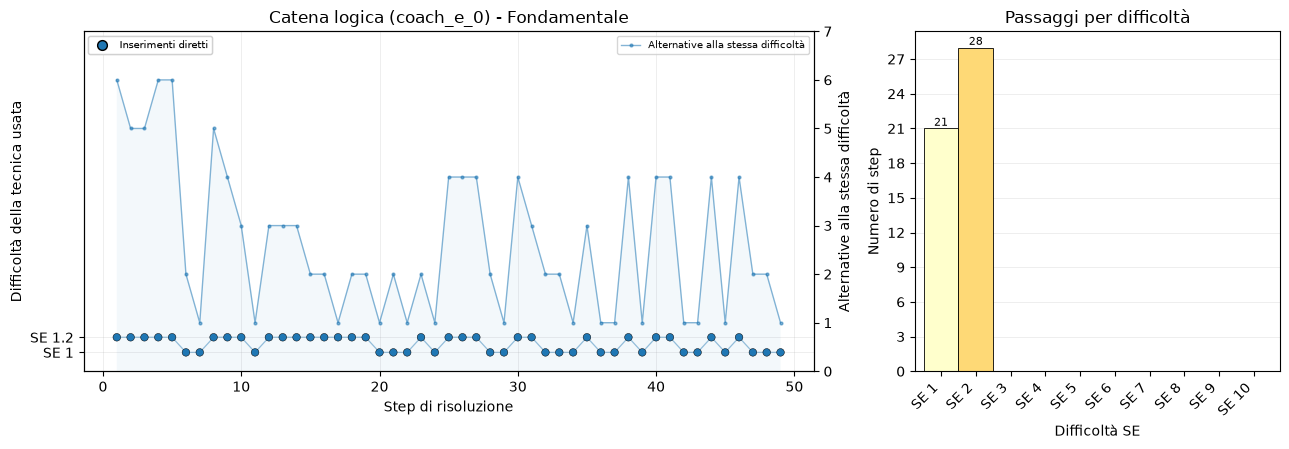

(<Figure size 1300x460 with 3 Axes>,
 (<Axes: title={'center': 'Catena logica (coach_e_0) - Fondamentale'}, xlabel='Step di risoluzione', ylabel='Difficoltà della tecnica usata'>,
  <Axes: title={'center': 'Passaggi per difficoltà'}, xlabel='Difficoltà SE', ylabel='Numero di step'>,
  <Axes: ylabel='Alternative alla stessa difficoltà'>))

In [ ]:
sv.plot_difficulty_chain(first_result)

Sudoku caricato
ID: e1e2d08ceb03386ebf4c
Nome: coach_e_0
Percorso: sudoku_data\puzzles\e1e2d08ceb03386ebf4c.json


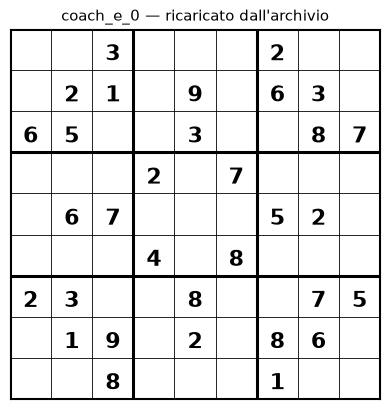

In [6]:
print("Sudoku caricato")
print("ID:", loaded_info["id"])
print("Nome:", loaded_info["name"])
print("Percorso:", loaded_info["path"])

sv.draw_grid(
    loaded_puzzle,
    title=f"{loaded_info['name']} — ricaricato dall'archivio",
)
plt.show()


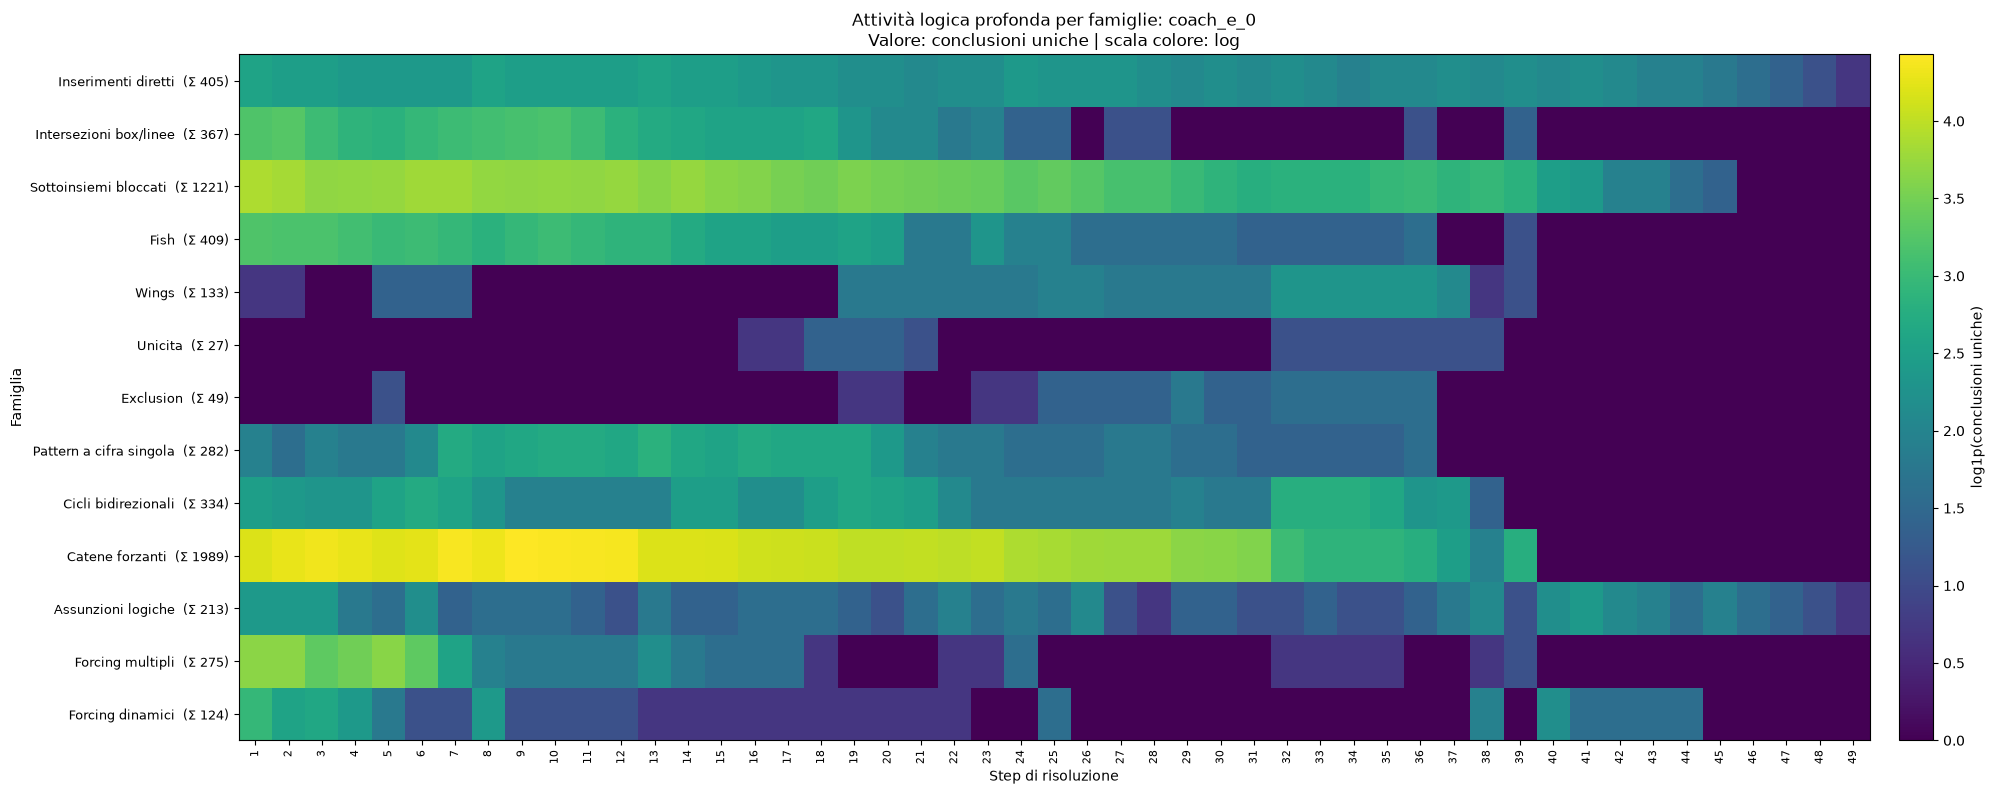

In [ ]:
sv.plot_technique_activity(first_result)
